In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import pickle
import json
from prophet import Prophet
from sklearn.metrics import mean_squared_error

df = pd.read_csv('../data/df_features.csv', parse_dates=['date'])

with open('../src/models/feature_cols.json', 'r') as f:
    feature_cols = json.load(f)

cutoff_date = '2015-12-31'
train = df[df['date'] <= cutoff_date].copy()
val   = df[df['date'] >  cutoff_date].copy()

print("Data loaded")
print("Unique items:", df['id'].nunique())

Importing plotly failed. Interactive plots will not work.


Data loaded
Unique items: 200


In [2]:
explanation = """
LightGBM vs Prophet — why use both?

LightGBM:
- Learns from engineered features (lags, rolling stats, calendar)
- Great at capturing complex feature interactions
- Needs manual feature engineering

Prophet:
- Built specifically for time series
- Automatically models trend + weekly + yearly seasonality
- Works per-item, doesn't need lag features
- Handles holidays natively

Combining both in an ensemble usually beats either alone,
because they capture different patterns and make different
types of errors that cancel out.
"""
print(explanation)


LightGBM vs Prophet — why use both?

LightGBM:
- Learns from engineered features (lags, rolling stats, calendar)
- Great at capturing complex feature interactions
- Needs manual feature engineering

Prophet:
- Built specifically for time series
- Automatically models trend + weekly + yearly seasonality
- Works per-item, doesn't need lag features
- Handles holidays natively

Combining both in an ensemble usually beats either alone,
because they capture different patterns and make different
types of errors that cancel out.



In [3]:
# Prophet needs columns named 'ds' (date) and 'y' (value)
# It trains PER ITEM — one model per SKU

sample_id = df['id'].unique()[0]
item_data = df[df['id'] == sample_id][['date', 'sales']].rename(
    columns={'date': 'ds', 'sales': 'y'}
)

item_train = item_data[item_data['ds'] <= cutoff_date]
item_val   = item_data[item_data['ds'] >  cutoff_date]

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
m.fit(item_train)

future = item_val[['ds']]
forecast = m.predict(future)

print("Test run successful")
print(forecast[['ds', 'yhat']].head())

10:36:44 - cmdstanpy - INFO - Chain [1] start processing
10:36:44 - cmdstanpy - INFO - Chain [1] done processing


Test run successful
          ds       yhat
0 2016-01-01   8.134475
1 2016-01-02  11.440863
2 2016-01-03   9.529313
3 2016-01-04   6.440489
4 2016-01-05   6.553763


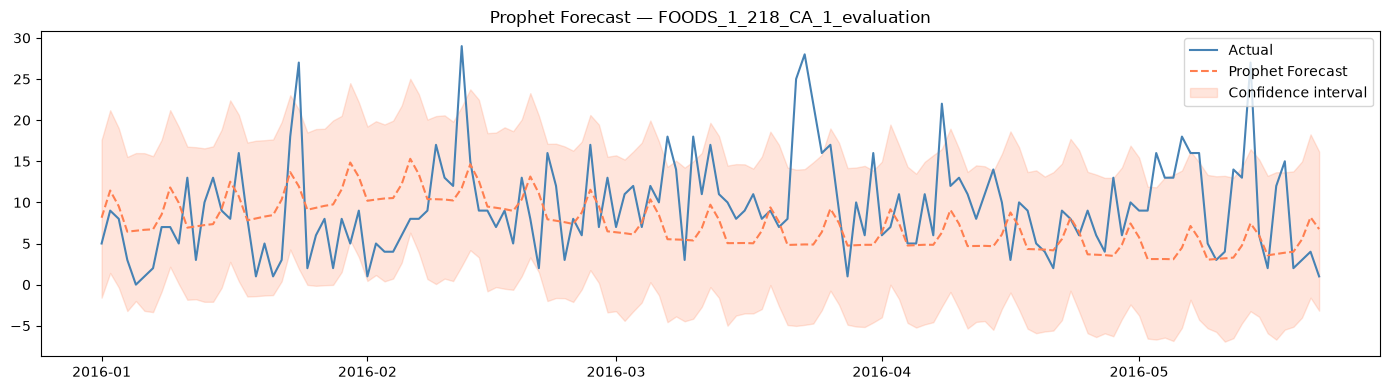

In [4]:
plt.figure(figsize=(14, 4))
plt.plot(item_val['ds'], item_val['y'].values, label='Actual', color='steelblue')
plt.plot(forecast['ds'], forecast['yhat'], label='Prophet Forecast',
         color='coral', linestyle='--')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                  alpha=0.2, color='coral', label='Confidence interval')
plt.title(f"Prophet Forecast — {sample_id}")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# This trains one Prophet model per item — takes a few minutes
# Prophet prints a lot of logs — that's normal, ignore them

import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

all_items = df['id'].unique()
prophet_results = {}

for i, item_id in enumerate(all_items):
    item_data = df[df['id'] == item_id][['date', 'sales']].rename(
        columns={'date': 'ds', 'sales': 'y'}
    )
    item_train = item_data[item_data['ds'] <= cutoff_date]
    item_val   = item_data[item_data['ds'] >  cutoff_date]

    if len(item_train) < 100:  # skip items with too little history
        continue

    try:
        m = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            seasonality_mode='multiplicative'
        )
        m.fit(item_train)

        future = item_val[['ds']]
        forecast = m.predict(future)

        prophet_results[item_id] = forecast[['ds', 'yhat']].set_index('ds')['yhat']

    except Exception as e:
        print(f"Skipped {item_id}: {e}")
        continue

    if (i + 1) % 10 == 0:
        print(f"Processed {i+1}/{len(all_items)} items")

print(f"\nDone. Prophet trained on {len(prophet_results)} items")

Processed 10/200 items
Processed 20/200 items
Processed 30/200 items
Processed 40/200 items
Processed 50/200 items
Processed 60/200 items
Processed 70/200 items
Processed 80/200 items
Processed 90/200 items
Processed 100/200 items
Processed 110/200 items
Processed 120/200 items
Processed 130/200 items
Processed 140/200 items
Processed 150/200 items
Processed 160/200 items
Processed 170/200 items
Processed 180/200 items
Processed 190/200 items
Processed 200/200 items

Done. Prophet trained on 200 items


In [6]:
val = val.copy()
val['prophet_pred'] = np.nan

for item_id, preds in prophet_results.items():
    mask = val['id'] == item_id
    dates = val.loc[mask, 'date']
    val.loc[mask, 'prophet_pred'] = dates.map(preds).values

# Clip negative predictions
val['prophet_pred'] = val['prophet_pred'].clip(lower=0)

print("Missing prophet predictions:", val['prophet_pred'].isnull().sum())
print("Total val rows:", len(val))

# Drop rows where prophet failed (if any)
val_clean = val.dropna(subset=['prophet_pred']).copy()
print("Clean val rows:", len(val_clean))

Missing prophet predictions: 0
Total val rows: 28600
Clean val rows: 28600


In [7]:
with open('../src/models/lgbm_best.pkl', 'rb') as f:
    lgbm_model = pickle.load(f)

X_val_clean = val_clean[feature_cols]
val_clean['lgbm_pred'] = np.clip(lgbm_model.predict(X_val_clean), 0, None)

print("LightGBM predictions added")
val_clean[['id', 'date', 'sales', 'lgbm_pred', 'prophet_pred']].head(10)

LightGBM predictions added


,id,date,sales,lgbm_pred,prophet_pred
1770,FOODS_1_218_CA_1_evaluation,2016-01-01,5,5.024052,8.134475
1771,FOODS_1_218_CA_1_evaluation,2016-01-02,9,7.395397,11.440863
1772,FOODS_1_218_CA_1_evaluation,2016-01-03,8,8.460041,9.529313
1773,FOODS_1_218_CA_1_evaluation,2016-01-04,3,6.205674,6.440489
1774,FOODS_1_218_CA_1_evaluation,2016-01-05,0,6.438800,6.553763
1775,FOODS_1_218_CA_1_evaluation,2016-01-06,1,5.785628,6.666562
1776,FOODS_1_218_CA_1_evaluation,2016-01-07,2,5.703205,6.727048
1777,FOODS_1_218_CA_1_evaluation,2016-01-08,7,5.901419,8.524778
1778,FOODS_1_218_CA_1_evaluation,2016-01-09,7,6.630618,11.813822
1779,FOODS_1_218_CA_1_evaluation,2016-01-10,5,7.048524,9.947760


In [8]:
rmse_lgbm = np.sqrt(
    mean_squared_error(val_clean['sales'], val_clean['lgbm_pred'])
)

rmse_prophet = np.sqrt(
    mean_squared_error(val_clean['sales'], val_clean['prophet_pred'])
)

print(f"LightGBM RMSE:  {rmse_lgbm:.4f}")
print(f"Prophet RMSE:   {rmse_prophet:.4f}")

LightGBM RMSE:  7.4279
Prophet RMSE:   11.4113


In [9]:
results = []

for w in [0.3, 0.4, 0.5, 0.6, 0.7]:
    ensemble_pred = (
        w * val_clean['lgbm_pred']
        + (1 - w) * val_clean['prophet_pred']
    )

    rmse = np.sqrt(
        mean_squared_error(
            val_clean['sales'],
            ensemble_pred
        )
    )

    results.append({
        'lgbm_weight': w,
        'prophet_weight': round(1 - w, 2),
        'rmse': round(rmse, 4)
    })

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

best_weight = results_df.loc[
    results_df['rmse'].idxmin(),
    'lgbm_weight'
]

print(f"\nBest LightGBM weight: {best_weight}")

 lgbm_weight  prophet_weight   rmse
         0.3             0.7 9.4613
         0.4             0.6 8.9114
         0.5             0.5 8.4286
         0.6             0.4 8.0252
         0.7             0.3 7.7135

Best LightGBM weight: 0.7


           Model      RMSE  Improvement vs LightGBM
   LightGBM only  7.427929                     0.00
    Prophet only 11.411297                   -53.63
Ensemble (w=0.7)  7.713496                    -3.84


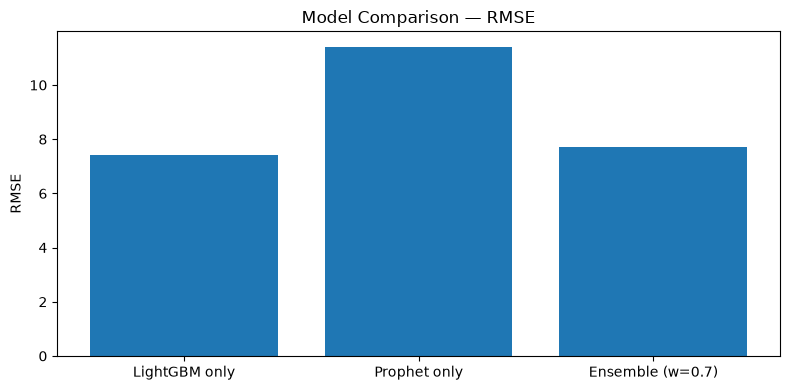

In [10]:
best_ensemble_pred = (
    best_weight * val_clean['lgbm_pred']
    + (1 - best_weight) * val_clean['prophet_pred']
)

rmse_ensemble = np.sqrt(
    mean_squared_error(
        val_clean['sales'],
        best_ensemble_pred
    )
)

comparison = pd.DataFrame({
    'Model': [
        'LightGBM only',
        'Prophet only',
        f'Ensemble (w={best_weight})'
    ],
    'RMSE': [
        rmse_lgbm,
        rmse_prophet,
        rmse_ensemble
    ]
})

comparison['Improvement vs LightGBM'] = (
    (comparison['RMSE'].iloc[0] - comparison['RMSE'])
    / comparison['RMSE'].iloc[0] * 100
).round(2)

print(comparison.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.bar(
    comparison['Model'],
    comparison['RMSE']
)
plt.title("Model Comparison — RMSE")
plt.ylabel("RMSE")
plt.tight_layout()
plt.savefig('../notebooks/model_comparison.png')
plt.show()

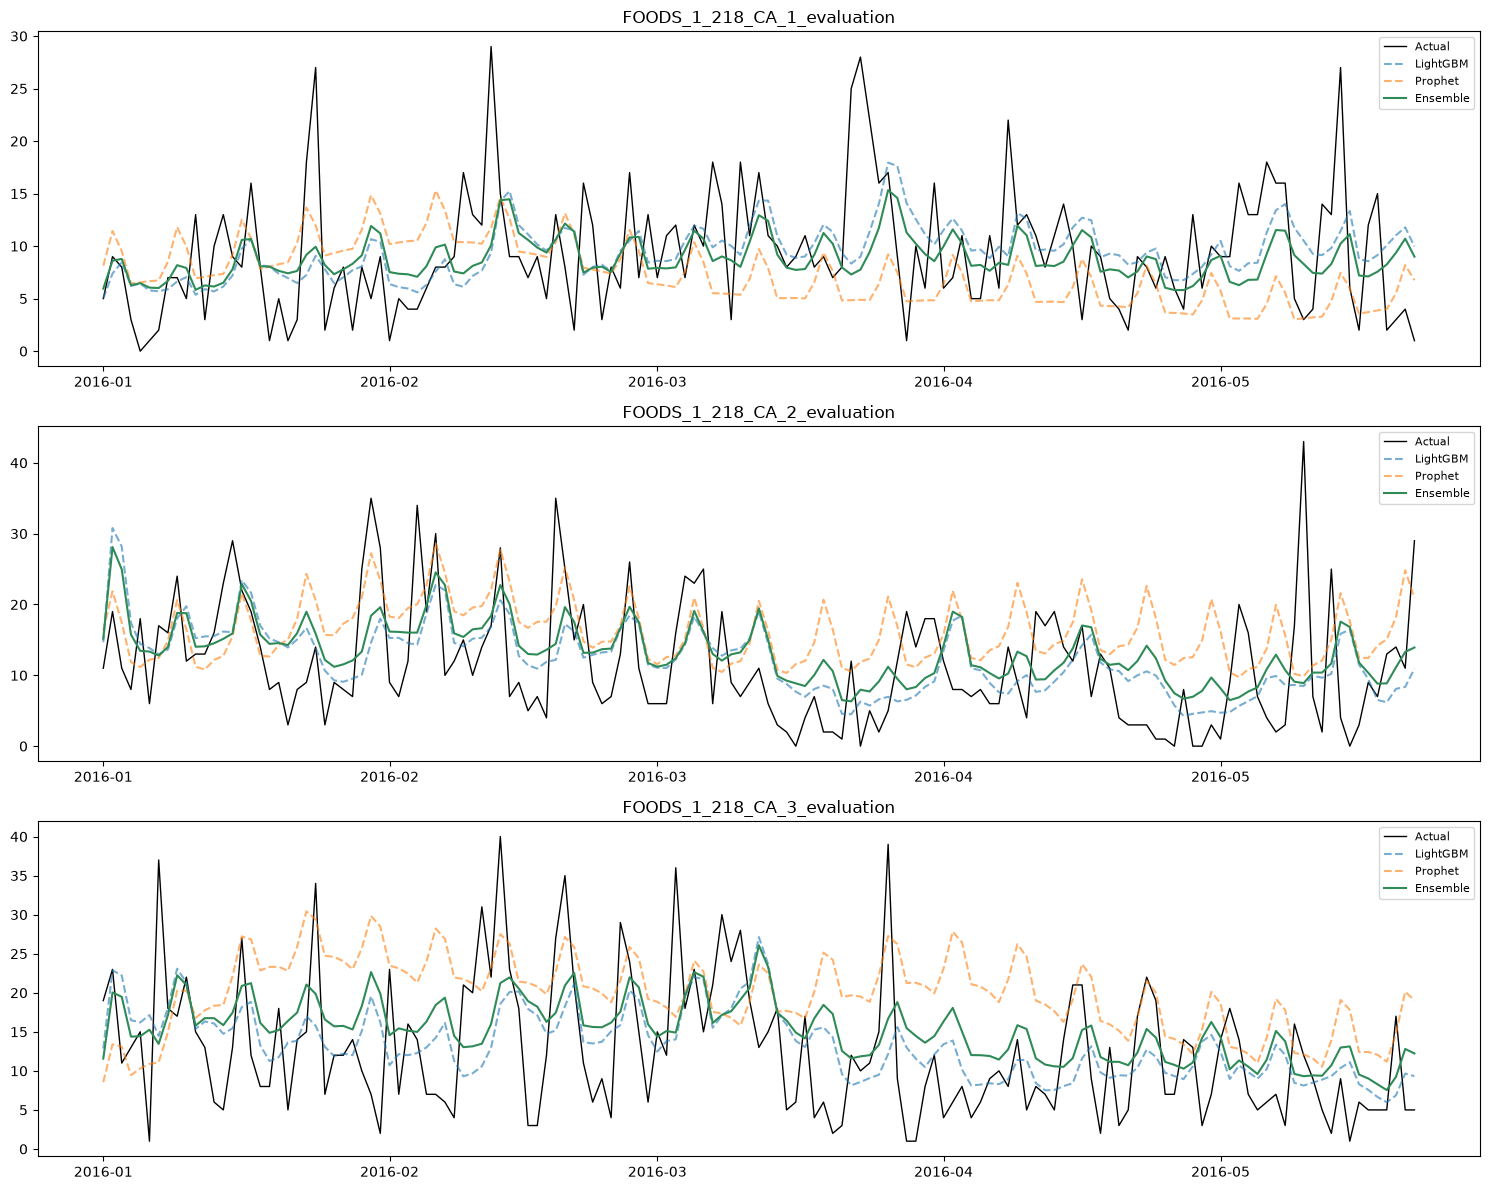

In [11]:
sample_items = val_clean['id'].unique()[:3]

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for i, item_id in enumerate(sample_items):
    mask = val_clean['id'] == item_id
    sub = val_clean[mask].sort_values('date')
    ensemble = best_weight * sub['lgbm_pred'] + (1 - best_weight) * sub['prophet_pred']

    axes[i].plot(sub['date'], sub['sales'], label='Actual', color='black', linewidth=1)
    axes[i].plot(sub['date'], sub['lgbm_pred'], label='LightGBM', alpha=0.6, linestyle='--')
    axes[i].plot(sub['date'], sub['prophet_pred'], label='Prophet', alpha=0.6, linestyle='--')
    axes[i].plot(sub['date'], ensemble, label='Ensemble', color='seagreen', linewidth=1.5)
    axes[i].set_title(item_id)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../notebooks/ensemble_predictions.png')
plt.show()

In [12]:
import json

ensemble_config = {
    'lgbm_weight': float(best_weight),
    'prophet_weight': float(round(1 - best_weight, 2)),
    'rmse_lgbm': float(rmse_lgbm),
    'rmse_prophet': float(rmse_prophet),
    'rmse_ensemble': float(rmse_ensemble)
}

with open('../src/models/ensemble_config.json', 'w') as f:
    json.dump(ensemble_config, f, indent=2)

val_clean[['id', 'date', 'sales', 'lgbm_pred', 'prophet_pred']].to_csv(
    '../data/val_predictions.csv',
    index=False
)

print("Saved ensemble_config.json")
print(ensemble_config)

Saved ensemble_config.json
{'lgbm_weight': 0.7, 'prophet_weight': 0.3, 'rmse_lgbm': 7.427928803763403, 'rmse_prophet': 11.411296777912105, 'rmse_ensemble': 7.713495963605831}
